# K-Moda MMM — Feature Engineering

**Input:** `data/processed/01_master_semanal.csv` — 2 620 filas × 34 columnas (10 ciudades × 262 semanas)  
**Output:** `data/processed/02_features_mmm.csv` — dataset listo para modelado

---

## Objetivo

Transformar las variables del master en **features preparadas para el MMM**:

| Bloque | Transformación | Por qué |
|---|---|---|
| Inversión en medios | Adstock geométrico | Modela la memoria acumulada de la publicidad |
| Inversión en medios | Saturación Hill | Modela rendimientos decrecientes |
| Tiempo | Tendencia lineal | Captura crecimiento orgánico de fondo |
| Tiempo | Términos de Fourier | Estacionalidad suave sin sobreajuste |
| Calendario | Flags binarios | Efectos promocionales / festivos |
| Panel | Dummies de ciudad | Fixed effects por mercado |
| Variable objetivo | Log-transform | Estabiliza varianza si es necesario |

---

## Estructura

1. Librerías y configuración de hiperparámetros  
2. Carga de datos  
3. Adstock por canal y ciudad  
4. Saturación Hill  
5. Variables de control (tendencia, estacionalidad, calendario, ciudad)  
6. Variable objetivo  
7. Partición temporal (train / test)  
8. Validación del dataset final  
9. Exportación  
10. Conclusiones y próximos pasos  


---
## 1. Librerías y configuración de hiperparámetros

In [28]:
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.append('../src')
from utils_mmm import (
    adstock_geometrico, hill_saturation,
    normalizar_mmm, cargar_master, PROC, FIGS
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
print('Librerías cargadas.')

Librerías cargadas.


In [29]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN CENTRAL — editar aquí antes de ejecutar el notebook
# ══════════════════════════════════════════════════════════════════════════════

CANALES_MEDIOS = [
    'inv_paid_search', 'inv_social_paid', 'inv_display',
    'inv_video_online', 'inv_email_crm',
    'inv_exterior', 'inv_radio_local', 'inv_prensa',
]

# Decay inicial por canal — valores explorados en EDA; se refinan en modelado
# 0.0 = sin memoria  |  0.9 = memoria muy larga
DECAY_INICIAL = {
    'inv_paid_search':  0.3,   # respuesta directa, efecto rápido
    'inv_social_paid':  0.4,
    'inv_display':      0.5,
    'inv_video_online': 0.5,
    'inv_email_crm':    0.2,   # transaccional, casi sin memoria
    'inv_exterior':     0.6,   # branding offline, memoria larga
    'inv_radio_local':  0.5,
    'inv_prensa':       0.4,
}

# Hill: K = punto de media saturación (None → se estima desde datos)
#        S = exponente de forma (2 es estándar de partida)
HILL_S_INICIAL = 2.0

# Semanas de Fourier (número de armónicos para la estacionalidad)
FOURIER_HARMONICS = 3

# Semanas de test (hold-out final, no tocar hasta modelado)
TEST_SEMANAS = 52  # ~1 año

print('Configuración registrada:')
for canal, decay in DECAY_INICIAL.items():
    print(f'  {canal:<25} decay={decay}')

# Lag temporal por canal (Ecuación 1 del PDF: X'_{t,m} = X_{t-L,m})
# Semanas de desfase entre gasto en medios y efecto en ventas observado
LAG_CANAL = {
    'inv_paid_search':  0,   # búsqueda de intención directa, efecto inmediato
    'inv_social_paid':  1,   # awareness → consideración (~1 semana)
    'inv_display':      1,   # display programático
    'inv_video_online': 1,   # vídeo digital
    'inv_email_crm':    0,   # transaccional, sin lag
    'inv_exterior':     2,   # branding offline diferido
    'inv_radio_local':  1,   # radio, 1 semana de digestión
    'inv_prensa':       2,   # prensa impresa, distribución + lectura diferida
}

print('\nLag temporal por canal:')
for canal, lag in LAG_CANAL.items():
    print(f'  {canal:<25}  L={lag}')


# ── Nota metodológica: curva de pérdida (Sección 2.3 del PDF) ────────────────
# sklearn ElasticNet no expone la loss por iteración. Para generar la curva
# pedagógica que Ricardo Sanz necesita ver (caída → meseta de convergencia)
# usamos el MAPE de cada fold del TimeSeriesSplit como proxy de la loss.
# Esta curva se genera automáticamente en el notebook 03_modelo_mmm_base.


Configuración registrada:
  inv_paid_search           decay=0.3
  inv_social_paid           decay=0.4
  inv_display               decay=0.5
  inv_video_online          decay=0.5
  inv_email_crm             decay=0.2
  inv_exterior              decay=0.6
  inv_radio_local           decay=0.5
  inv_prensa                decay=0.4

Lag temporal por canal:
  inv_paid_search            L=0
  inv_social_paid            L=1
  inv_display                L=1
  inv_video_online           L=1
  inv_email_crm              L=0
  inv_exterior               L=2
  inv_radio_local            L=1
  inv_prensa                 L=2


---
## 2. Carga de datos

In [30]:
df = cargar_master()  # función de utils_mmm: parsea fechas, ordena por ciudad+semana

print(f'Shape:   {df.shape}')
print(f'Periodo: {df["semana_inicio"].min().date()}  →  {df["semana_inicio"].max().date()}')
print(f'Ciudades: {sorted(df["ciudad"].unique())}')
print(f'Semanas por ciudad: {df.groupby("ciudad").size().unique()[0]}')
print(f'\nNulos: {df.isnull().sum().sum()}')
df.head(3)

Shape:   (2610, 34)
Periodo: 2020-01-06  →  2024-12-30
Ciudades: ['A Coruna', 'Barcelona', 'Bilbao', 'Madrid', 'Malaga', 'Murcia', 'Palma', 'Sevilla', 'Valencia', 'Zaragoza']
Semanas por ciudad: 261

Nulos: 0


,ciudad,semana_inicio,ventas_eur,unidades,margen_eur,inv_display,inv_email_crm,inv_exterior,inv_paid_search,inv_prensa,...,dias_semana_santa,dias_payday,dias_festivo,dias_vacaciones_escolares,dias_incidencia_ecommerce,temperatura_media,lluvia_media,turismo_indice_medio,anio,semana_iso
0,A Coruna,2020-01-06,0.0,0.0,0.0,581.95,948.84,2035.84,1467.96,781.85,...,0,0,0,0,0,8.457143,82.000000,22.257143,2020,2
1,A Coruna,2020-01-13,0.0,0.0,0.0,439.07,784.27,1455.77,2233.14,718.70,...,0,0,0,0,0,9.985714,80.557143,17.971429,2020,3
2,A Coruna,2020-01-20,0.0,0.0,0.0,659.10,307.21,969.03,2376.30,651.94,...,0,2,0,0,0,10.528571,71.385714,20.457143,2020,4


In [31]:
# ── Verificar que todos los canales tienen inversión positiva ─────────────────
print('Estadísticos de inversión semanal por canal (todas ciudades):')
df[CANALES_MEDIOS].describe().round(0)

Estadísticos de inversión semanal por canal (todas ciudades):


,inv_paid_search,inv_social_paid,inv_display,inv_video_online,inv_email_crm,inv_exterior,inv_radio_local,inv_prensa
count,2610.0,2610.0,2610.0,2610.0,2610.0,2610.0,2610.0,2610.0
mean,5134.0,4015.0,1841.0,3483.0,1127.0,2769.0,2531.0,2088.0
std,3034.0,2336.0,1198.0,2044.0,855.0,1497.0,1504.0,1179.0
min,732.0,655.0,131.0,550.0,35.0,362.0,269.0,330.0
25%,3083.0,2402.0,1020.0,2067.0,566.0,1677.0,1490.0,1240.0
50%,4349.0,3418.0,1534.0,2960.0,917.0,2463.0,2165.0,1832.0
75%,6254.0,5005.0,2295.0,4385.0,1406.0,3544.0,3161.0,2661.0
max,24908.0,25121.0,10218.0,16716.0,10630.0,12101.0,11419.0,8823.0


In [32]:
# ── Lag temporal (Ecuación 1 PDF: X'_{t,m} = X_{t-L,m}) ─────────────────────
# Desplaza la inversión L semanas hacia adelante dentro de cada ciudad.
# La inversión raw (inv_*) se conserva para cálculo de presupuesto en el simulador.

def apply_lag_panel(df, col, lag):
    """Desplaza la serie temporal lag semanas dentro de cada ciudad."""
    if lag == 0:
        return df[col].copy()
    resultado = pd.Series(0.0, index=df.index)
    for ciudad in df['ciudad'].unique():
        mask = df['ciudad'] == ciudad
        resultado.loc[mask] = df.loc[mask, col].shift(lag).fillna(0).values
    return resultado


print('Aplicando lag temporal por canal:')
for canal in CANALES_MEDIOS:
    lag = LAG_CANAL[canal]
    df[f'{canal}_lagged'] = apply_lag_panel(df, canal, lag)
    tag = f'L={lag} semana(s)' if lag > 0 else 'sin lag'
    print(f'  {canal:<25}  {tag}')

print('\nColumnas inv_*_lagged creadas. Inversión raw (inv_*) conservada para simulador.')


Aplicando lag temporal por canal:
  inv_paid_search            sin lag
  inv_social_paid            L=1 semana(s)
  inv_display                L=1 semana(s)
  inv_video_online           L=1 semana(s)
  inv_email_crm              sin lag
  inv_exterior               L=2 semana(s)
  inv_radio_local            L=1 semana(s)
  inv_prensa                 L=2 semana(s)

Columnas inv_*_lagged creadas. Inversión raw (inv_*) conservada para simulador.


---
## 3. Adstock geométrico por canal y ciudad

### Concepto

El **adstock geométrico** convierte la inversión semanal bruta $x_t$ en la «presión publicitaria» acumulada $A_t$:  

$$A_t = x_t + \lambda \cdot A_{t-1}$$

donde $\lambda \in [0,1)$ es la **tasa de retención** (cuánto del efecto de la semana anterior persiste).  

**Importante:** la transformación se aplica **dentro de cada ciudad** por separado, porque las series de inversión de Madrid y Barcelona son independientes.

### Selección del decay óptimo

Buscamos el $\lambda$ que maximiza la correlación entre el adstock y las ventas (en datos de entrenamiento).  
Este valor será un punto de partida; el modelo calibrará el decay final mediante optimización.

In [33]:
def adstock_panel(df, col, decay):
    resultado = pd.Series(0.0, index=df.index)
    for ciudad in df["ciudad"].unique():
        mask = df["ciudad"] == ciudad
        city_serie = df.loc[mask, col].fillna(0)
        resultado.loc[mask] = adstock_geometrico(city_serie, decay).values
    return resultado


# ── Bounds economicos por tipo de canal ──────────────────────────────────
# Sin restricciones, el grid search siempre elige lambda=0.90 porque el
# adstock con lambda alta es una suma acumulada que imita la tendencia
# creciente de las ventas, no la memoria real del medio.
DECAY_BOUNDS = {
    "inv_paid_search":  (0.0, 0.50),  # respuesta directa
    "inv_social_paid":  (0.2, 0.60),  # awareness digital
    "inv_display":      (0.2, 0.65),  # display
    "inv_video_online": (0.2, 0.65),  # video
    "inv_email_crm":    (0.0, 0.35),  # transaccional: casi sin memoria
    "inv_exterior":     (0.3, 0.75),  # branding offline
    "inv_radio_local":  (0.2, 0.65),  # radio
    "inv_prensa":       (0.2, 0.60),  # prensa
}

# ── Detrend de ventas antes de la correlacion ────────────────────────────
# Correlacionar adstock con ventas raw captura la tendencia creciente del
# negocio (lambda->1 acumula como suma parcial que correlaciona con
# cualquier serie creciente). Los residuos aislan la respuesta al medio.
from sklearn.linear_model import LinearRegression as _LR

n_train = df["semana_inicio"].nunique() - TEST_SEMANAS
semanas_train = sorted(df["semana_inicio"].unique())[:n_train]
mask_train = df["semana_inicio"].isin(semanas_train)

_semana_idx = {s: i for i, s in enumerate(sorted(df["semana_inicio"].unique()))}
df["_t"] = df["semana_inicio"].map(_semana_idx)
_trend_reg = _LR().fit(df.loc[mask_train, ["_t"]], df.loc[mask_train, "ventas_eur"])
ventas_detrend = pd.Series(
    df["ventas_eur"].values - _trend_reg.predict(df[["_t"]].values),
    index=df.index
)
df.drop(columns=["_t"], inplace=True)

# ── Grid search: decay optimo dentro de bounds por canal ─────────────────
DECAY_GRID = np.round(np.arange(0.0, 0.95, 0.05), 2)

decay_optimo = {}
corr_por_decay = {}

for canal in CANALES_MEDIOS:
    lo, hi = DECAY_BOUNDS[canal]
    corrs_all = []
    for d in DECAY_GRID:
        ads = adstock_panel(df, f"{canal}_lagged", d)
        c   = ventas_detrend[mask_train].corr(ads[mask_train])
        corrs_all.append(float(c))
    corr_por_decay[canal] = corrs_all
    # Seleccionar el mejor dentro del rango permitido
    valid = [(d, corrs_all[i]) for i, d in enumerate(DECAY_GRID) if lo <= d <= hi]
    best_d, _ = max(valid, key=lambda x: x[1])
    decay_optimo[canal] = best_d

print(f"Periodo de entrenamiento: {len(semanas_train)} semanas")
print(f"Periodo de test:          {TEST_SEMANAS} semanas")
print("Decay optimo por canal (corr detrended, dentro de bounds):")
for canal, d in decay_optimo.items():
    idx  = list(DECAY_GRID).index(d)
    corr = corr_por_decay[canal][idx]
    init = DECAY_INICIAL[canal]
    lo, hi = DECAY_BOUNDS[canal]
    tag  = "OK" if abs(d - init) < 0.15 else f"<- ajustado desde {init}"
    print(f"  {canal:<25}  lambda={d:.2f}  corr={corr:.3f}  bounds=[{lo:.2f},{hi:.2f}]  {tag}")


Periodo de entrenamiento: 209 semanas
Periodo de test:          52 semanas
Decay optimo por canal (corr detrended, dentro de bounds):
  inv_paid_search            lambda=0.50  corr=0.472  bounds=[0.00,0.50]  <- ajustado desde 0.3
  inv_social_paid            lambda=0.60  corr=0.483  bounds=[0.20,0.60]  <- ajustado desde 0.4
  inv_display                lambda=0.65  corr=0.474  bounds=[0.20,0.65]  <- ajustado desde 0.5
  inv_video_online           lambda=0.65  corr=0.451  bounds=[0.20,0.65]  <- ajustado desde 0.5
  inv_email_crm              lambda=0.35  corr=0.312  bounds=[0.00,0.35]  OK
  inv_exterior               lambda=0.75  corr=0.439  bounds=[0.30,0.75]  <- ajustado desde 0.6
  inv_radio_local            lambda=0.65  corr=0.439  bounds=[0.20,0.65]  <- ajustado desde 0.5
  inv_prensa                 lambda=0.60  corr=0.434  bounds=[0.20,0.60]  <- ajustado desde 0.4


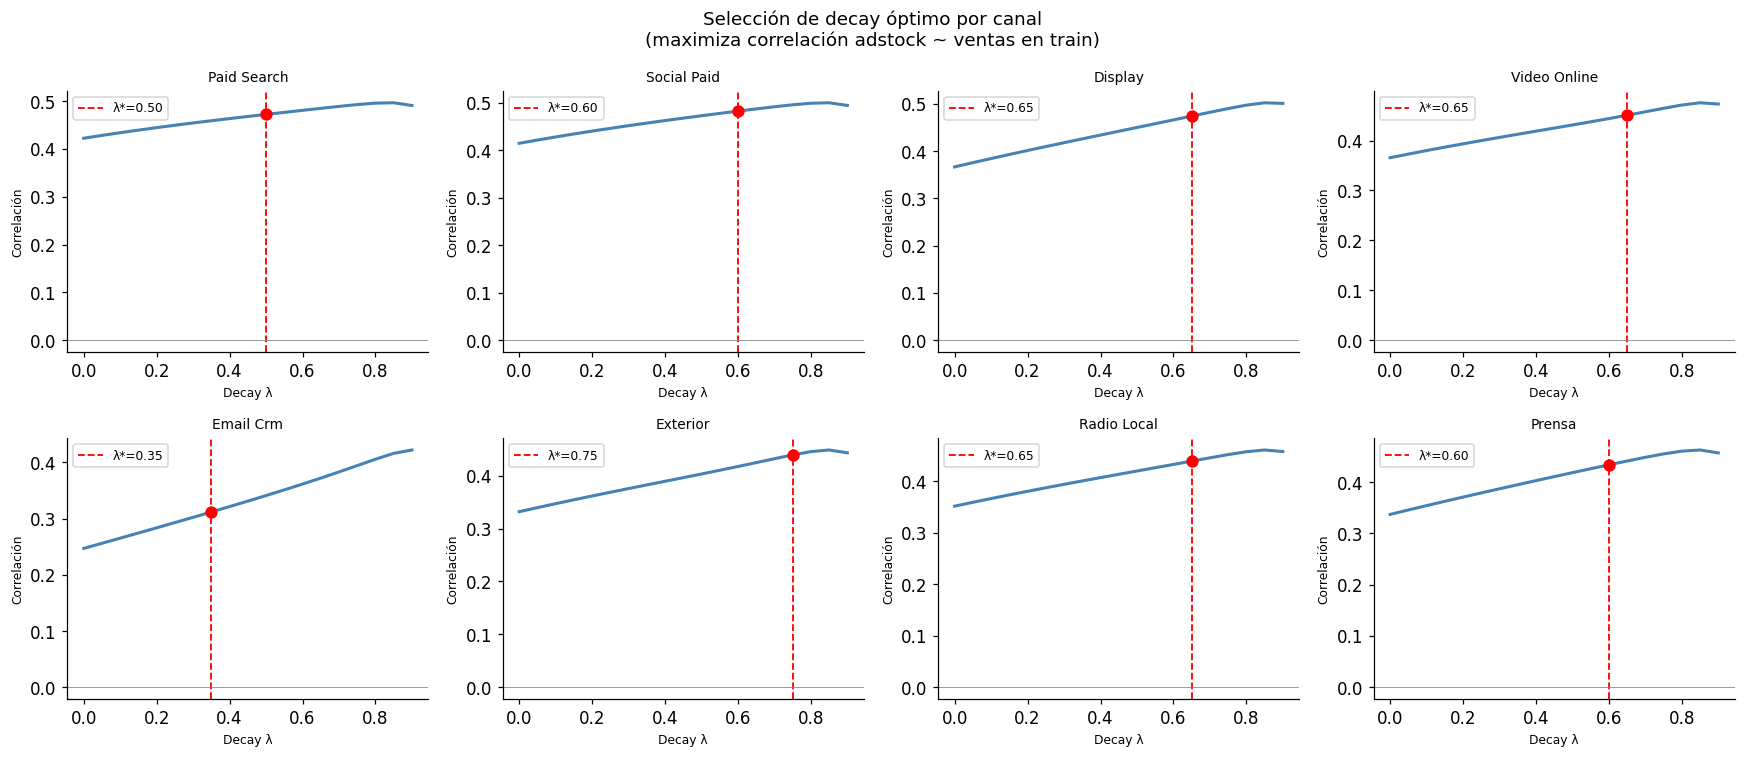

In [34]:
# ── Visualización de la búsqueda de decay ────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
axes = axes.flatten()

for ax, canal in zip(axes, CANALES_MEDIOS):
    corrs = corr_por_decay[canal]
    ax.plot(DECAY_GRID, corrs, color='steelblue', linewidth=2)
    opt_d = decay_optimo[canal]
    opt_c = corrs[list(DECAY_GRID).index(opt_d)]
    ax.axvline(opt_d, color='red', linestyle='--', linewidth=1.2,
               label=f'λ*={opt_d:.2f}')
    ax.scatter([opt_d], [opt_c], color='red', zorder=5, s=50)
    ax.set_title(canal.replace('inv_', '').replace('_', ' ').title(), fontsize=9)
    ax.set_xlabel('Decay λ', fontsize=8)
    ax.set_ylabel('Correlación', fontsize=8)
    ax.legend(fontsize=8)
    ax.axhline(0, color='gray', linewidth=0.5)

plt.suptitle('Selección de decay óptimo por canal\n(maximiza correlación adstock ~ ventas en train)',
             fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / 'decay_grid_search.png', bbox_inches='tight')
plt.show()

In [35]:
# ── Aplicar adstock óptimo a cada canal ──────────────────────────────────────
# Usamos el decay encontrado por grid search (no el inicial de config)
for canal in CANALES_MEDIOS:
    df[f'{canal}_adstock'] = adstock_panel(df, f'{canal}_lagged', decay_optimo[canal])

print('Columnas adstock creadas (desde inversión con lag):')
ads_cols = [c for c in df.columns if c.endswith('_adstock')]
print(df[ads_cols].describe().round(0))

Columnas adstock creadas (desde inversión con lag):
       inv_paid_search_adstock  inv_social_paid_adstock  inv_display_adstock  \
count                   2610.0                   2610.0               2610.0   
mean                   10215.0                   9893.0               5175.0   
std                     5387.0                   4975.0               2634.0   
min                     1468.0                      0.0                  0.0   
25%                     6603.0                   6590.0               3305.0   
50%                     8869.0                   8651.0               4583.0   
75%                    12201.0                  11980.0               6269.0   
max                    38547.0                  36251.0              17826.0   

       inv_video_online_adstock  inv_email_crm_adstock  inv_exterior_adstock  \
count                    2610.0                 2610.0                2610.0   
mean                     9771.0                 1729.0             

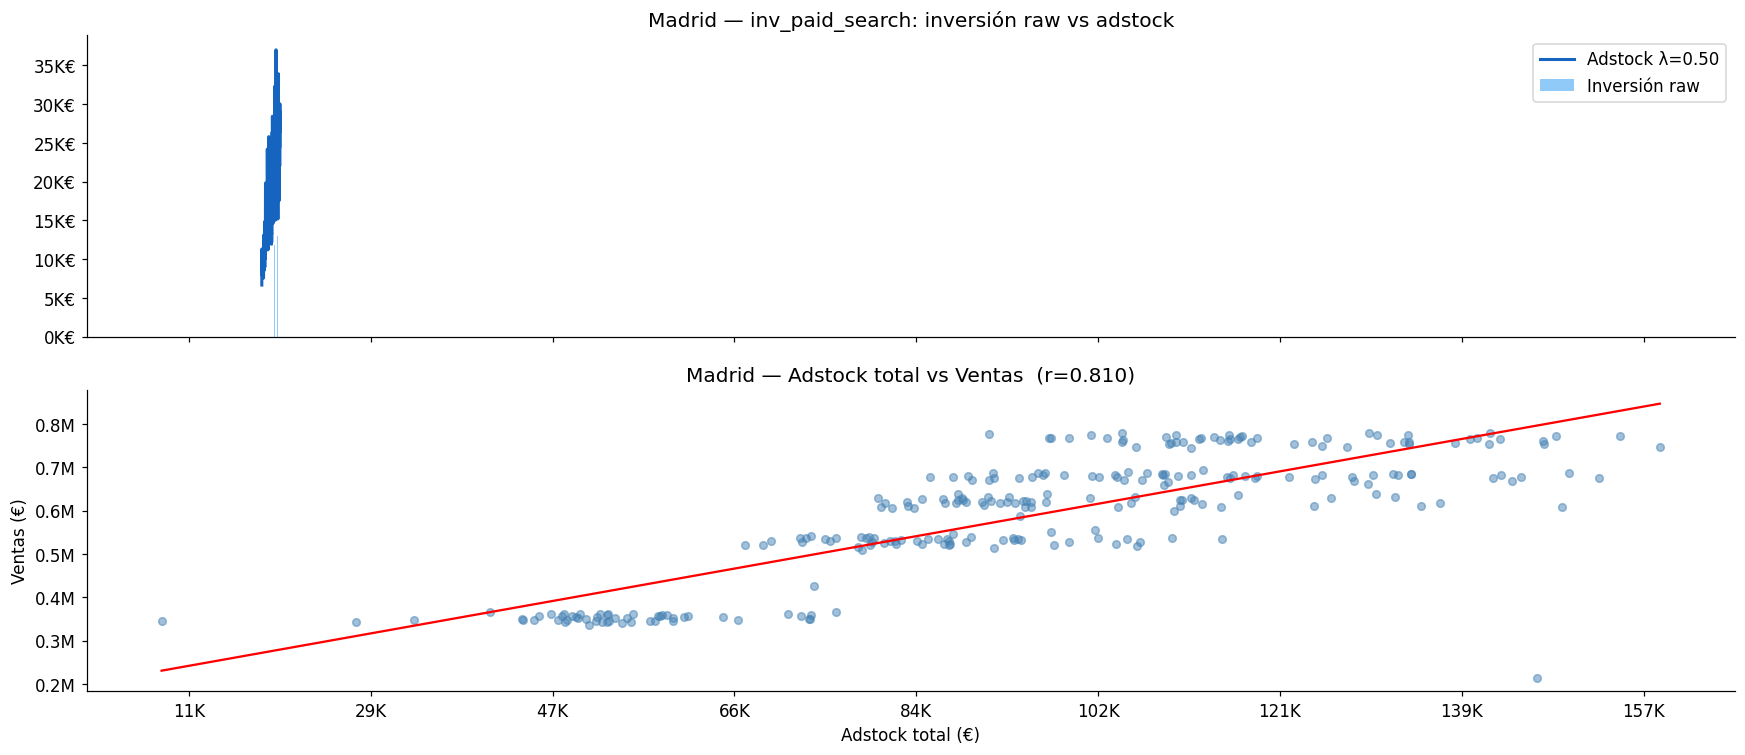

In [36]:
# ── Visualizar raw vs adstock para Madrid (canal Paid Search) ─────────────────
canal_demo = 'inv_paid_search'
ciudad_demo = 'Madrid'
df_demo = df[df['ciudad'] == ciudad_demo].copy()

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

axes[0].bar(df_demo['semana_inicio'], df_demo[canal_demo],
            color='#90CAF9', label='Inversión raw')
axes[0].plot(df_demo['semana_inicio'], df_demo[f'{canal_demo}_adstock'],
             color='#1565C0', linewidth=2, label=f'Adstock λ={decay_optimo[canal_demo]:.2f}')
axes[0].set_title(f'{ciudad_demo} — {canal_demo}: inversión raw vs adstock')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K€'))
axes[0].legend()

# Scatter adstock vs ventas (todos los canales, Madrid)
x = df_demo[[f'{c}_adstock' for c in CANALES_MEDIOS]].sum(axis=1)
y = df_demo['ventas_eur']
r = np.corrcoef(x, y)[0, 1]
axes[1].scatter(x, y, alpha=0.5, s=25, color='steelblue')
z = np.polyfit(x, y, 1)
xr = np.linspace(x.min(), x.max(), 100)
axes[1].plot(xr, np.poly1d(z)(xr), color='red', linewidth=1.5)
axes[1].set_title(f'{ciudad_demo} — Adstock total vs Ventas  (r={r:.3f})')
axes[1].set_xlabel('Adstock total (€)')
axes[1].set_ylabel('Ventas (€)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig(FIGS / 'adstock_demo.png', bbox_inches='tight')
plt.show()

---
## 4. Saturación Hill — rendimientos decrecientes

### Concepto

La función Hill transforma el adstock en un efecto acotado $\in [0,1]$ que representa la **presión publicitaria efectiva**:  

$$f(A_t) = \frac{A_t^S}{K^S + A_t^S}$$

- **K** (punto de media saturación): el nivel de adstock donde se alcanza el 50% del efecto máximo.  
  → Estimamos K como la **mediana** del adstock por canal (punto central de los datos observados).
- **S** (curvatura): $S=1$ → cóncava desde el origen; $S=2$ → forma en S. Usamos $S=2$ como punto de partida.

> **Nota:** La elección de K y S afecta directamente los coeficientes del modelo. Estos parámetros se refinan en el notebook de modelado. Aquí establecemos valores informativos.

In [37]:
# ── Estimar K como mediana del adstock por canal (pooled, solo train) ─────────
HILL_PARAMS = {}
for canal in CANALES_MEDIOS:
    ads_col = f'{canal}_adstock'
    K_est = df.loc[mask_train, ads_col].median()
    K_est = K_est if K_est > 0 else df.loc[mask_train, ads_col].mean()
    HILL_PARAMS[canal] = {'K': K_est, 'S': HILL_S_INICIAL}

print(f'Parámetros Hill estimados (S={HILL_S_INICIAL}):')
print(f'{"Canal":<25} {"K (€)":>12} {"S":>5}')
print('-' * 45)
for canal, p in HILL_PARAMS.items():
    print(f'{canal:<25} {p["K"]:>12,.0f} {p["S"]:>5.1f}')

Parámetros Hill estimados (S=2.0):
Canal                            K (€)     S
---------------------------------------------
inv_paid_search                  8,233   2.0
inv_social_paid                  8,017   2.0
inv_display                      4,212   2.0
inv_video_online                 7,979   2.0
inv_email_crm                    1,379   2.0
inv_exterior                     9,538   2.0
inv_radio_local                  5,890   2.0
inv_prensa                       4,448   2.0


In [38]:
# ── Aplicar Hill sobre el adstock de cada canal ───────────────────────────────
for canal in CANALES_MEDIOS:
    ads_col = f'{canal}_adstock'
    p = HILL_PARAMS[canal]
    df[f'{canal}_transformed'] = hill_saturation(df[ads_col], p['K'], p['S'])

transformed_cols = [f'{c}_transformed' for c in CANALES_MEDIOS]
print('Rango de variables transformadas (deben estar en [0, 1]):')
df[transformed_cols].agg(['min', 'max', 'mean']).round(4)

Rango de variables transformadas (deben estar en [0, 1]):


,inv_paid_search_transformed,inv_social_paid_transformed,inv_display_transformed,inv_video_online_transformed,inv_email_crm_transformed,inv_exterior_transformed,inv_radio_local_transformed,inv_prensa_transformed
min,0.0308,0.0000,0.0000,0.0000,0.0163,0.0000,0.0000,0.0000
max,0.9564,0.9534,0.9471,0.9460,0.9879,0.8948,0.9532,0.9101
mean,0.5373,0.5402,0.5363,0.5405,0.5285,0.5193,0.5355,0.5211


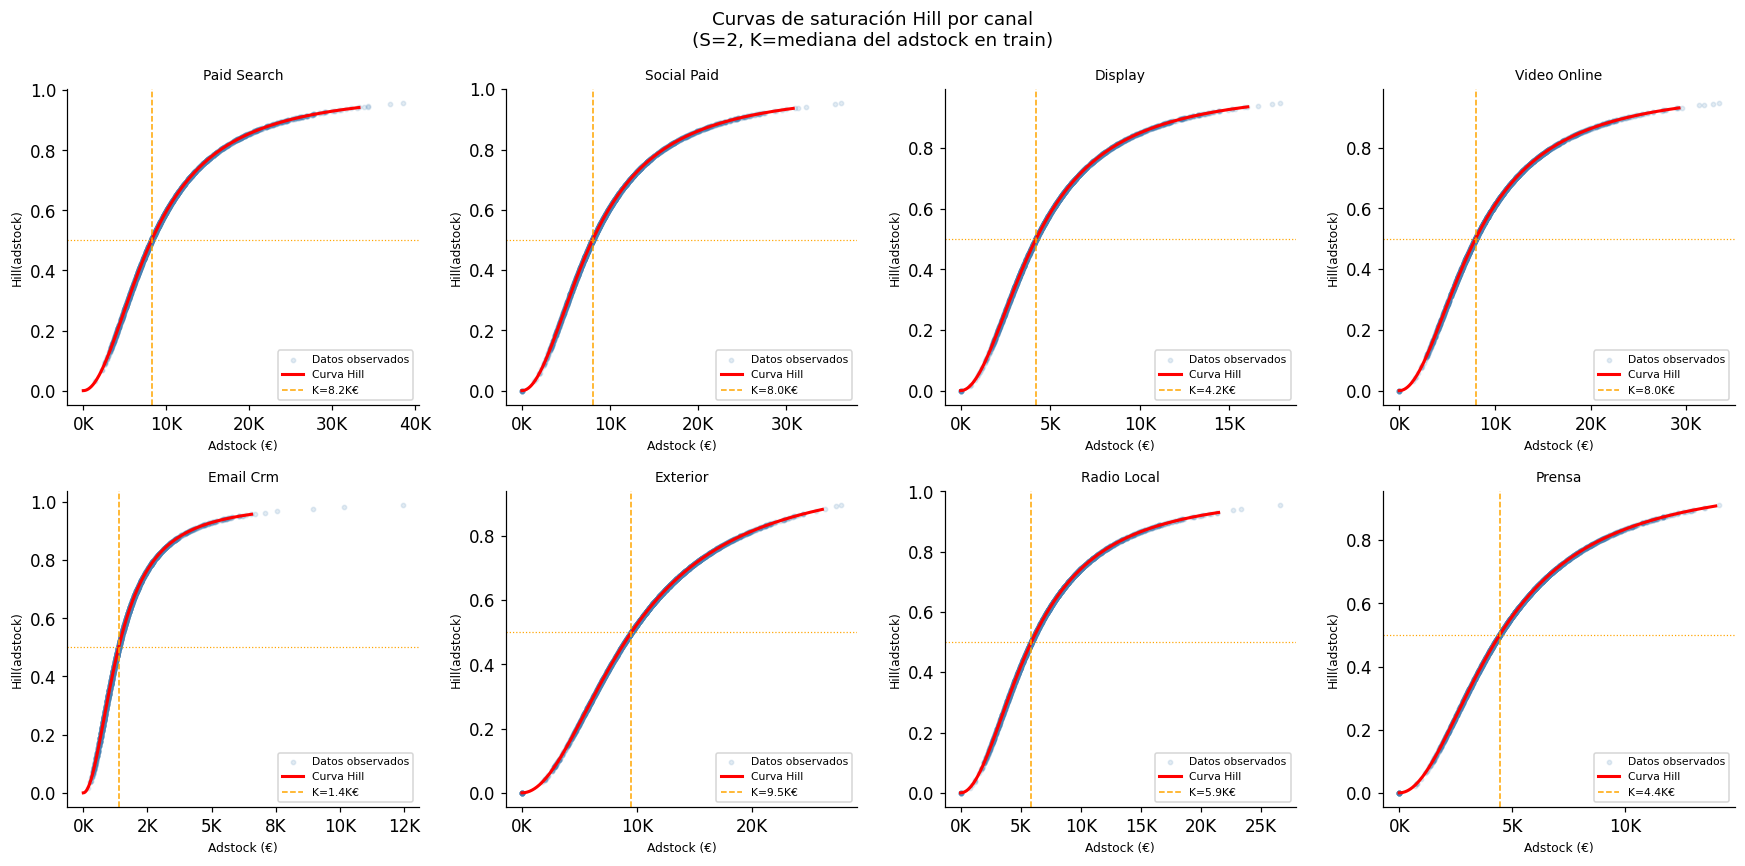

In [39]:
# ── Visualizar curvas Hill con distribución de datos observados ───────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, canal in zip(axes, CANALES_MEDIOS):
    p = HILL_PARAMS[canal]
    ads_vals = df[f'{canal}_adstock']
    x_max    = ads_vals.quantile(0.99) * 1.2
    x_curve  = np.linspace(0, x_max, 500)
    y_curve  = hill_saturation(x_curve, p['K'], p['S'])

    # Datos observados
    ax.scatter(ads_vals, df[f'{canal}_transformed'],
               alpha=0.15, s=8, color='steelblue', label='Datos observados')
    # Curva teórica
    ax.plot(x_curve, y_curve, color='red', linewidth=2, label='Curva Hill')
    # Marcar K
    ax.axvline(p['K'], color='orange', linestyle='--', linewidth=1,
               label=f'K={p["K"]/1e3:.1f}K€')
    ax.axhline(0.5, color='orange', linestyle=':', linewidth=0.8)

    ax.set_title(canal.replace('inv_', '').replace('_', ' ').title(), fontsize=9)
    ax.set_xlabel('Adstock (€)', fontsize=8)
    ax.set_ylabel('Hill(adstock)', fontsize=8)
    ax.legend(fontsize=7)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.suptitle('Curvas de saturación Hill por canal\n(S=2, K=mediana del adstock en train)',
             fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / 'hill_saturation_curves.png', bbox_inches='tight')
plt.show()

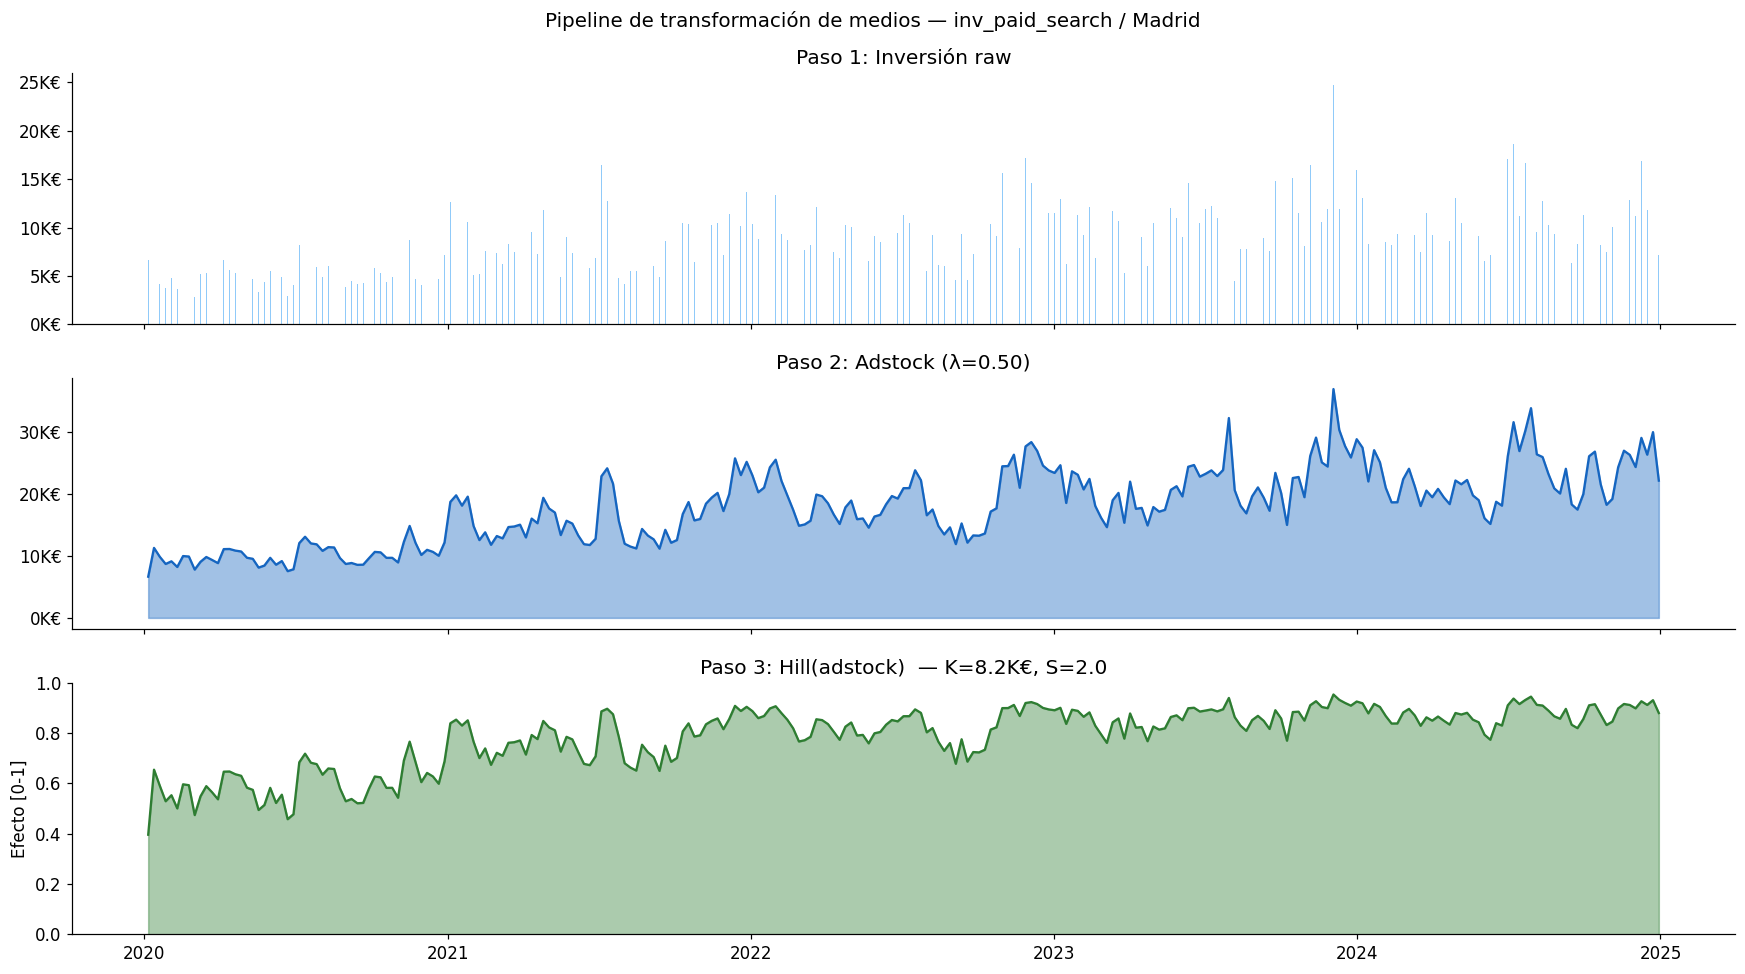

In [40]:
# ── Pipeline completo: raw → adstock → Hill para un canal demo ───────────────
canal_demo = 'inv_paid_search'
ciudad_demo = 'Madrid'
df_demo = df[df['ciudad'] == ciudad_demo].sort_values('semana_inicio').copy()

p = HILL_PARAMS[canal_demo]

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

# Raw
axes[0].bar(df_demo['semana_inicio'], df_demo[canal_demo],
            color='#90CAF9')
axes[0].set_title('Paso 1: Inversión raw')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K€'))

# Adstock
axes[1].fill_between(df_demo['semana_inicio'], df_demo[f'{canal_demo}_adstock'],
                     alpha=0.4, color='#1565C0')
axes[1].plot(df_demo['semana_inicio'], df_demo[f'{canal_demo}_adstock'],
             color='#1565C0', linewidth=1.5)
axes[1].set_title(f'Paso 2: Adstock (λ={decay_optimo[canal_demo]:.2f})')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K€'))

# Hill
axes[2].fill_between(df_demo['semana_inicio'], df_demo[f'{canal_demo}_transformed'],
                     alpha=0.4, color='#2E7D32')
axes[2].plot(df_demo['semana_inicio'], df_demo[f'{canal_demo}_transformed'],
             color='#2E7D32', linewidth=1.5)
axes[2].set_title(f'Paso 3: Hill(adstock)  — K={p["K"]/1e3:.1f}K€, S={p["S"]}')
axes[2].set_ylim(0, 1)
axes[2].set_ylabel('Efecto [0-1]')

plt.suptitle(f'Pipeline de transformación de medios — {canal_demo} / {ciudad_demo}',
             fontsize=13)
plt.tight_layout()
plt.savefig(FIGS / 'pipeline_transformacion.png', bbox_inches='tight')
plt.show()

---
## 5. Variables de control

El MMM necesita aislar el efecto de los medios del resto de factores que mueven las ventas.  
Las variables de control capturan:

- **Tendencia:** el crecimiento orgánico del negocio independiente de la publicidad
- **Estacionalidad:** patrones repetitivos anuales (Rebajas, Navidad, verano...)
- **Efectos de calendario:** promociones específicas, festivos, paydays
- **Efectos de mercado:** diferencias estructurales entre ciudades

Sin estos controles, el modelo podría atribuir a los medios efectos que en realidad tienen otras causas.

trend:     rango [0.000, 1.000]
log_trend: rango [0.000, 1.000]


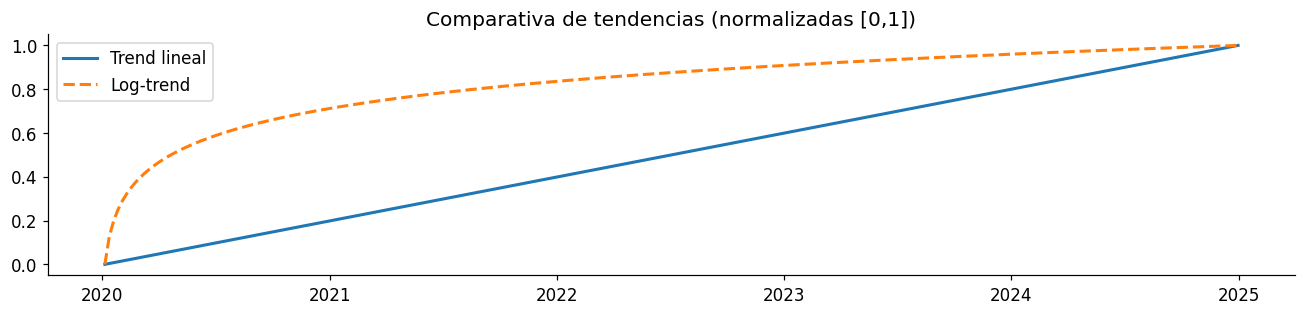


Usaremos log_trend como variable de tendencia (más realista para retail).


In [41]:
# ── 5.1 Tendencia ─────────────────────────────────────────────────────────────
# Índice temporal normalizado [0, 1] calculado sobre la serie única de semanas
semanas_unicas = sorted(df['semana_inicio'].unique())
n_semanas = len(semanas_unicas)

semana_to_idx = {s: i for i, s in enumerate(semanas_unicas)}
df['trend'] = df['semana_inicio'].map(semana_to_idx) / (n_semanas - 1)

# Alternativa log-trend (más realista para negocios con crecimiento no lineal)
df['trend_idx_raw'] = df['semana_inicio'].map(semana_to_idx) + 1  # evitar log(0)
df['log_trend'] = np.log(df['trend_idx_raw'])
df['log_trend'] = (df['log_trend'] - df['log_trend'].min()) / \
                  (df['log_trend'].max() - df['log_trend'].min())

print(f'trend:     rango [{df["trend"].min():.3f}, {df["trend"].max():.3f}]')
print(f'log_trend: rango [{df["log_trend"].min():.3f}, {df["log_trend"].max():.3f}]')

# Visualizar ambas tendencias
fig, ax = plt.subplots(figsize=(12, 3))
x = semanas_unicas
t_lineal = [semana_to_idx[s] / (n_semanas - 1) for s in x]
t_log    = df.groupby('semana_inicio')['log_trend'].first().reindex(x).values
ax.plot(x, t_lineal, label='Trend lineal', linewidth=2)
ax.plot(x, t_log,    label='Log-trend',    linewidth=2, linestyle='--')
ax.set_title('Comparativa de tendencias (normalizadas [0,1])')
ax.legend()
plt.tight_layout()
plt.show()
print('\nUsaremos log_trend como variable de tendencia (más realista para retail).')

Términos de Fourier creados (6 columnas): ['sin_1', 'cos_1', 'sin_2', 'cos_2', 'sin_3', 'cos_3']


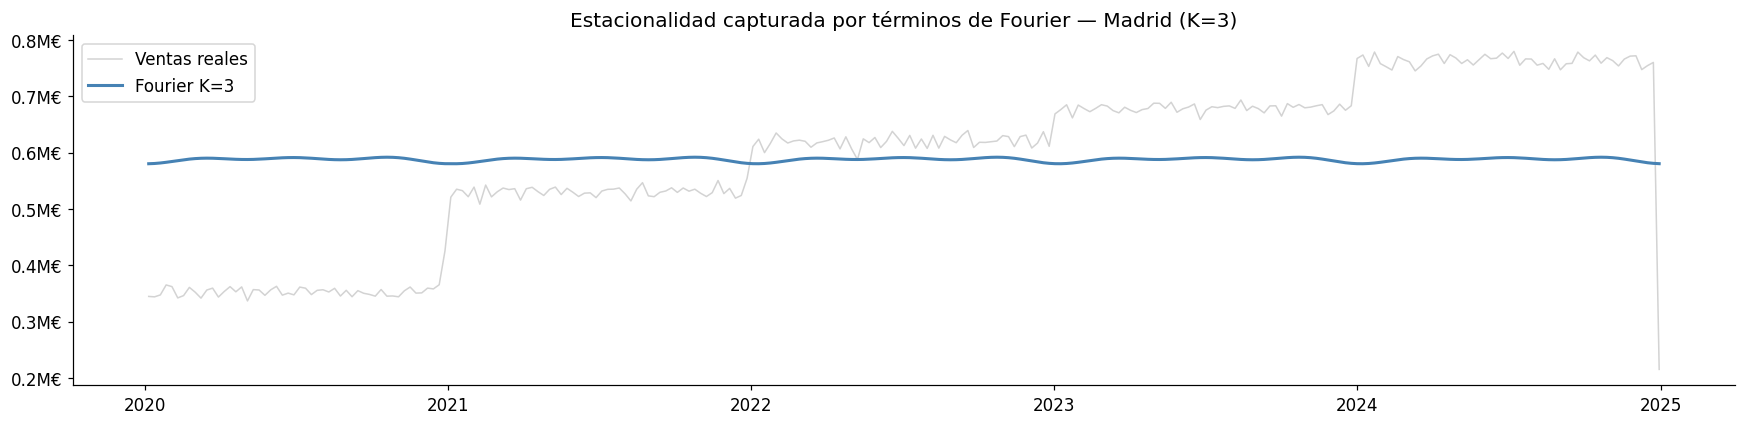

In [42]:
# ── 5.2 Estacionalidad con términos de Fourier ────────────────────────────────
#
# Usamos armónicos de Fourier en lugar de dummies de semana porque:
#   - Usa solo 2×K parámetros (vs 51 dummies de semana)
#   - Produce curvas estacionales suaves (menos sobreajuste)
#   - Funciona bien incluso con semanas escasamente observadas
#
for k in range(1, FOURIER_HARMONICS + 1):
    df[f'sin_{k}'] = np.sin(2 * np.pi * k * df['semana_iso'] / 52)
    df[f'cos_{k}'] = np.cos(2 * np.pi * k * df['semana_iso'] / 52)

fourier_cols = [f'{fn}_{k}'
                for k in range(1, FOURIER_HARMONICS + 1)
                for fn in ('sin', 'cos')]

print(f'Términos de Fourier creados ({len(fourier_cols)} columnas): {fourier_cols}')

# Visualizar la estacionalidad capturada por Fourier (una ciudad)
from sklearn.linear_model import LinearRegression

df_mad = df[df['ciudad'] == 'Madrid'].sort_values('semana_inicio')
reg = LinearRegression().fit(df_mad[fourier_cols], df_mad['ventas_eur'])
y_fourier = reg.predict(df_mad[fourier_cols])

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df_mad['semana_inicio'], df_mad['ventas_eur'],
        color='lightgray', linewidth=1, label='Ventas reales')
ax.plot(df_mad['semana_inicio'], y_fourier,
        color='steelblue', linewidth=2, label=f'Fourier K={FOURIER_HARMONICS}')
ax.set_title(f'Estacionalidad capturada por términos de Fourier — Madrid (K={FOURIER_HARMONICS})')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M€'))
ax.legend()
plt.tight_layout()
plt.show()

In [43]:
# ── 5.3 Variables de calendario ───────────────────────────────────────────────
# Ya están en el master como conteos de días activos por semana.
# Convertimos a variables binarias (la semana tuvo o no ese efecto).

FLAGS_CONT = [
    'dias_rebajas', 'dias_black_friday', 'dias_navidad',
    'dias_semana_santa', 'dias_payday', 'dias_festivo',
    'dias_vacaciones_escolares', 'dias_incidencia_ecommerce',
]
for col in FLAGS_CONT:
    df[col.replace('dias_', 'flag_')] = (df[col] > 0).astype(int)

# Verificar proporción de semanas activas por flag
flag_cols = [col.replace('dias_', 'flag_') for col in FLAGS_CONT]
pct_activo = df[flag_cols].mean() * 100
print('% de semanas con el flag activo (pooled todas las ciudades):')
for col, pct in pct_activo.sort_values(ascending=False).items():
    print(f'  {col:<35} {pct:.1f}%')

% de semanas con el flag activo (pooled todas las ciudades):
  flag_payday                         57.1%
  flag_vacaciones_escolares           27.2%
  flag_rebajas                        25.7%
  flag_incidencia_ecommerce           12.3%
  flag_navidad                        8.0%
  flag_black_friday                   5.0%
  flag_semana_santa                   3.8%
  flag_festivo                        1.3%


In [44]:
# ── 5.4 Variables continuas de entorno (normalizadas) ────────────────────────
# temperatura_media y turismo_indice_medio pueden afectar la demanda base.
# Las normalizamos para mejorar la estabilidad numérica del modelo.

vars_entorno = ['temperatura_media', 'lluvia_media', 'turismo_indice_medio']

for col in vars_entorno:
    media  = df.loc[mask_train, col].mean()
    std    = df.loc[mask_train, col].std()
    df[f'{col}_z'] = (df[col] - media) / (std if std > 0 else 1)

entorno_z_cols = [f'{c}_z' for c in vars_entorno]
print('Variables de entorno normalizadas (z-score sobre train):')
df[entorno_z_cols].describe().round(3)

Variables de entorno normalizadas (z-score sobre train):


,temperatura_media_z,lluvia_media_z,turismo_indice_medio_z
count,2610.000,2610.000,2610.000
mean,0.003,-0.004,0.003
std,1.000,1.000,1.000
min,-2.450,-2.280,-1.609
25%,-0.831,-0.767,-0.776
50%,-0.012,-0.107,-0.303
75%,0.854,0.542,0.684
max,2.223,3.512,3.144


In [45]:
# ── 5.5 Fixed effects de ciudad ───────────────────────────────────────────────
# Capturan diferencias estructurales de nivel entre mercados.
# Con 10 ciudades usamos Barcelona como referencia (mayor ciudad).
# Se generan 9 dummies (n_ciudades - 1) para evitar trampa de perfecta colinealidad.

ciudad_ref     = 'Barcelona'
ciudades_dummy = [c for c in sorted(df['ciudad'].unique()) if c != ciudad_ref]

for ciudad in ciudades_dummy:
    safe = ciudad.lower().replace(' ', '_')
    df[f'ciudad_{safe}'] = (df['ciudad'] == ciudad).astype(int)

ciudad_dummy_cols = [f'ciudad_{c.lower().replace(" ", "_")}' for c in ciudades_dummy]
print(f'Referencia: {ciudad_ref}')
print(f'Dummies creadas ({len(ciudad_dummy_cols)}): {ciudad_dummy_cols}')
print()

ventas_por_ciudad = df.groupby('ciudad')['ventas_eur'].mean().sort_values(ascending=False)
print('Venta semanal media por ciudad:')
for ciudad, v in ventas_por_ciudad.items():
    ref = ' ← referencia' if ciudad == ciudad_ref else ''
    print(f'  {ciudad:<15} {v:>12,.0f} €{ref}')


Referencia: Barcelona
Dummies creadas (9): ['ciudad_a_coruna', 'ciudad_bilbao', 'ciudad_madrid', 'ciudad_malaga', 'ciudad_murcia', 'ciudad_palma', 'ciudad_sevilla', 'ciudad_valencia', 'ciudad_zaragoza']

Venta semanal media por ciudad:
  Barcelona            588,766 € ← referencia
  Madrid               587,807 €
  Bilbao               587,487 €
  Sevilla              587,162 €
  Valencia             586,711 €
  A Coruna                   0 €
  Murcia                     0 €
  Malaga                     0 €
  Palma                      0 €
  Zaragoza                   0 €


---
## 6. Variable objetivo

Evaluamos si la variable objetivo (`ventas_eur`) debe transformarse.  

La **log-transformación** es habitual en MMM porque:
- Estabiliza la varianza si ésta crece con el nivel de ventas (heteroscedasticidad)
- Hace que los coeficientes se interpreten como **elasticidades** (% de cambio en ventas por % de cambio en medios)
- Reduce el impacto de outliers

Mantenemos **ambas versiones** en el dataset y dejamos la elección final al notebook de modelado.

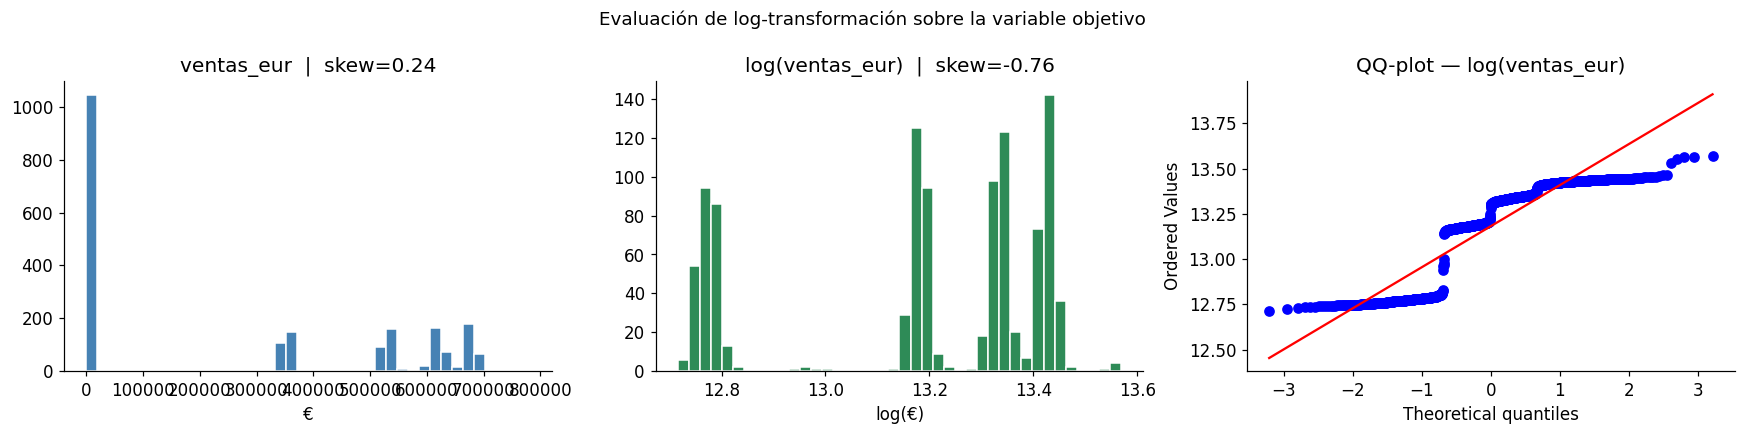

Shapiro p-value — ventas_eur:      0.0000
Shapiro p-value — log(ventas_eur): 0.0000
log_ventas_eur añadida. Ceros en ventas_eur: 1305


In [46]:
# ── Evaluación de la necesidad de log-transform ─────────────────────────────────────────────
v = df.loc[mask_train, 'ventas_eur']
v_pos = v[v > 0]  # excluir ceros (semanas sin ventas) antes del log
log_v = np.log(v_pos)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribución original
axes[0].hist(v, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title(f'ventas_eur  |  skew={v.skew():.2f}')
axes[0].set_xlabel('€')

# Log
axes[1].hist(log_v, bins=40, color='seagreen', edgecolor='white')
axes[1].set_title(f'log(ventas_eur)  |  skew={log_v.skew():.2f}')
axes[1].set_xlabel('log(€)')

# QQ-plot sobre log
stats.probplot(log_v, dist='norm', plot=axes[2])
axes[2].set_title('QQ-plot — log(ventas_eur)')

plt.suptitle('Evaluación de log-transformación sobre la variable objetivo', fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / 'target_transform.png', bbox_inches='tight')
plt.show()

stat_orig, p_orig = stats.shapiro(v_pos.sample(min(500, len(v_pos)), random_state=42))
stat_log,  p_log  = stats.shapiro(log_v.sample(min(500, len(log_v)), random_state=42))
print(f'Shapiro p-value — ventas_eur:      {p_orig:.4f}')
print(f'Shapiro p-value — log(ventas_eur): {p_log:.4f}')

# Usar log1p para manejar ceros en todo el dataset
df['log_ventas_eur'] = np.log1p(df['ventas_eur'])
print(f'log_ventas_eur añadida. Ceros en ventas_eur: {(df["ventas_eur"]==0).sum()}')


---
## 7. Partición temporal — Train / Test

En series temporales **no se usa validación cruzada aleatoria** porque rompería la dependencia temporal y produciría estimaciones optimistas.  

Usamos una **partición temporal secuencial**:
- **Train:** todo el histórico excepto el último año (~80%)
- **Test:** últimas 52 semanas (~20%) — el modelo nunca verá estos datos hasta la evaluación final

> Los hiperparámetros de adstock y Hill se seleccionaron **solo en train** (ver Sección 3).

Fecha de corte: 2024-01-08



,Inicio,Fin,Observaciones (filas)
split,,,
test,2024-01-08,2024-12-30,520
train,2020-01-06,2024-01-01,2090


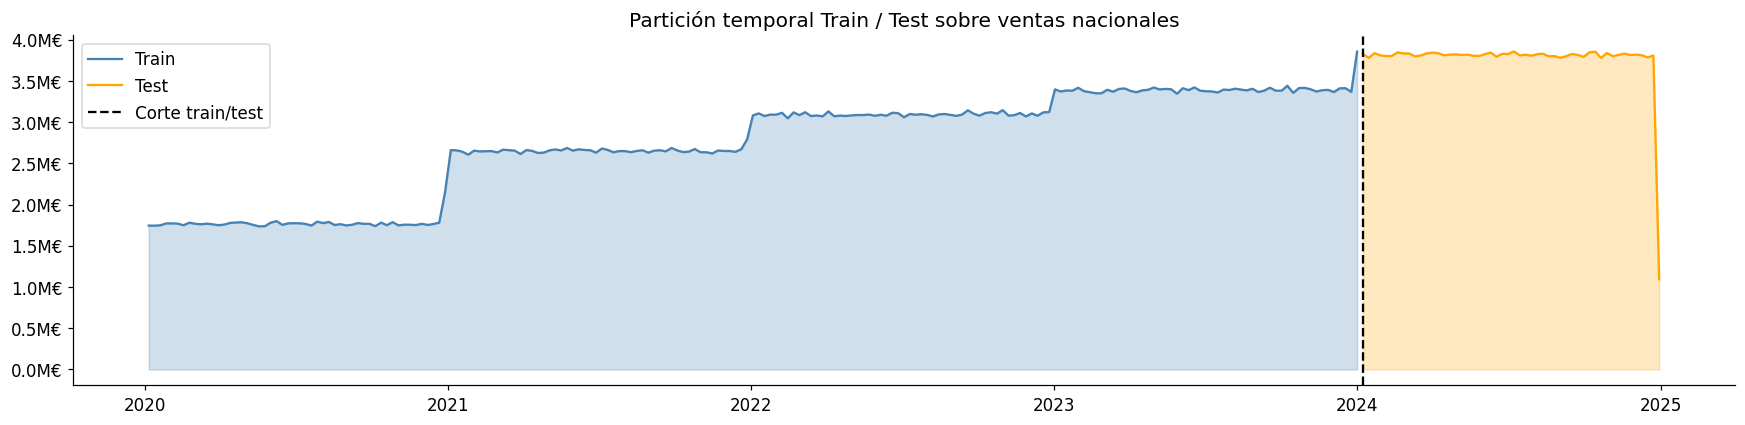

In [47]:
# ── Marcar train / test ───────────────────────────────────────────────────────
fecha_corte = pd.Timestamp(sorted(df['semana_inicio'].unique())[-TEST_SEMANAS])
df['split'] = np.where(df['semana_inicio'] < fecha_corte, 'train', 'test')

split_summary = df.groupby('split')['semana_inicio'].agg(['min', 'max', 'count'])
split_summary.columns = ['Inicio', 'Fin', 'Observaciones (filas)']
print(f'Fecha de corte: {fecha_corte.date()}')
print()
display(split_summary)

# Visualizar el corte sobre la serie de ventas
ventas_nac = df.groupby(['semana_inicio', 'split'])['ventas_eur'].sum().reset_index()

fig, ax = plt.subplots(figsize=(16, 4))
for split, color, label in [('train', 'steelblue', 'Train'), ('test', 'orange', 'Test')]:
    sub = ventas_nac[ventas_nac['split'] == split]
    ax.fill_between(sub['semana_inicio'], sub['ventas_eur'], alpha=0.25, color=color)
    ax.plot(sub['semana_inicio'], sub['ventas_eur'], color=color, linewidth=1.5, label=label)

ax.axvline(fecha_corte, color='black', linestyle='--', linewidth=1.5, label='Corte train/test')
ax.set_title('Partición temporal Train / Test sobre ventas nacionales')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M€'))
ax.legend()
plt.tight_layout()
plt.savefig(FIGS / 'train_test_split.png', bbox_inches='tight')
plt.show()

---
## 8. Validación del dataset de features

Antes de exportar, verificamos:
1. **Correlaciones post-transformación** — las variables de medios deben tener correlación más alta con ventas que las versiones raw
2. **Factor de Inflación de Varianza (VIF)** — detecta multicolinealidad severa entre features
3. **Esquema final** — lista completa de features con descripción

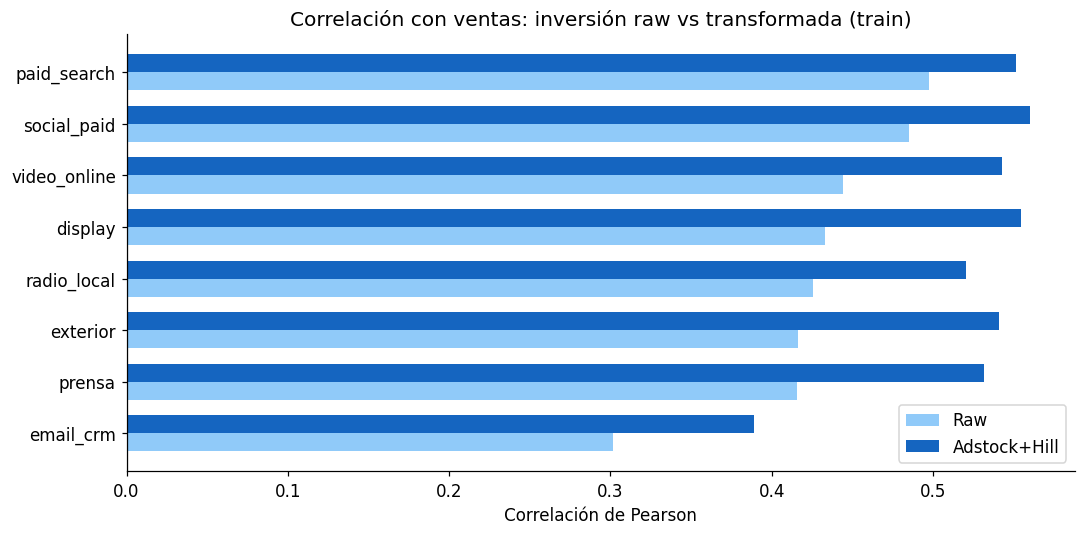

Diferencia de correlación (transformada − raw):
  email_crm                  +0.088
  prensa                     +0.116
  exterior                   +0.124
  radio_local                +0.095
  display                    +0.122
  video_online               +0.099
  social_paid                +0.075
  paid_search                +0.054


In [48]:
# ── Comparativa: correlación raw vs transformed con ventas ───────────────────
df_train = df[df['split'] == 'train']

corr_raw   = {c.replace('inv_', ''): df_train['ventas_eur'].corr(df_train[c])
              for c in CANALES_MEDIOS}
corr_trans = {c.replace('inv_', ''): df_train['ventas_eur'].corr(df_train[f'{c}_transformed'])
              for c in CANALES_MEDIOS}

comp = pd.DataFrame({'Raw': corr_raw, 'Adstock+Hill': corr_trans}).sort_values('Raw')

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comp))
w = 0.35
ax.barh(x - w/2, comp['Raw'],          w, label='Raw',          color='#90CAF9')
ax.barh(x + w/2, comp['Adstock+Hill'], w, label='Adstock+Hill', color='#1565C0')
ax.set_yticks(x)
ax.set_yticklabels(comp.index)
ax.axvline(0, color='black', linewidth=0.7)
ax.set_title('Correlación con ventas: inversión raw vs transformada (train)')
ax.set_xlabel('Correlación de Pearson')
ax.legend()
plt.tight_layout()
plt.savefig(FIGS / 'corr_raw_vs_transformed.png', bbox_inches='tight')
plt.show()

print('Diferencia de correlación (transformada − raw):')
for canal in comp.index:
    delta = comp.loc[canal, 'Adstock+Hill'] - comp.loc[canal, 'Raw']
    signo = '+' if delta >= 0 else ''
    print(f'  {canal:<25}  {signo}{delta:.3f}')

In [49]:
# ── Factor de Inflación de Varianza (VIF) ─────────────────────────────────────
# VIF > 10 indica multicolinealidad severa → revisar si hay features redundantes.
# Calculamos sobre el conjunto de features del modelo (sin target, sin IDs).

FEATURES_MODELO = (
    transformed_cols       # medios transformados
    + ['log_trend']        # tendencia
    + fourier_cols         # estacionalidad
    + flag_cols            # calendario
    + entorno_z_cols       # entorno
    + ciudad_dummy_cols    # fixed effects ciudad
)

X_vif = df_train[FEATURES_MODELO].dropna()

vif_df = pd.DataFrame({
    'Feature': FEATURES_MODELO,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

# Marcar problemáticos
vif_df['Estado'] = vif_df['VIF'].apply(
    lambda v: 'ALTO (>10)' if v > 10 else ('MEDIO (5-10)' if v > 5 else 'OK')
)

print('VIF por feature:')
display(vif_df.style.apply(
    lambda r: ['background-color: #FFCDD2' if r['Estado'] == 'ALTO (>10)'
               else ('background-color: #FFF9C4' if r['Estado'] == 'MEDIO (5-10)'
                     else '') for _ in r],
    axis=1
))

VIF por feature:


,Feature,VIF,Estado
0,log_trend,200.364648,ALTO (>10)
1,inv_video_online_transformed,71.513801,ALTO (>10)
2,inv_exterior_transformed,69.762638,ALTO (>10)
3,inv_social_paid_transformed,65.403363,ALTO (>10)
4,inv_radio_local_transformed,61.248812,ALTO (>10)
5,inv_paid_search_transformed,52.545547,ALTO (>10)
6,inv_display_transformed,42.562307,ALTO (>10)
7,inv_prensa_transformed,41.093936,ALTO (>10)
8,cos_1,25.238257,ALTO (>10)
9,temperatura_media_z,18.165931,ALTO (>10)


In [50]:
# ── Acción sobre features con VIF alto ───────────────────────────────────────
# Los términos de Fourier pueden tener VIF alto entre sí (correlación cruzada).
# Esto es esperado y no problemático si se usan juntos como bloque estacional.
# Inspeccionamos solo las features de medios y control no-Fourier.

vif_no_fourier = vif_df[~vif_df['Feature'].str.startswith(('sin_', 'cos_'))]
problematicos  = vif_no_fourier[vif_no_fourier['VIF'] > 10]

if len(problematicos):
    print('Features con VIF > 10 (excluidos Fourier):')
    display(problematicos)
    print('\nAcción recomendada: revisar si alguna de estas features es colineal con otra '
          'y considerar eliminarla o crear una versión combinada.')
else:
    print('Ninguna feature de control o medios supera VIF=10. El dataset es apto para modelado.')

Features con VIF > 10 (excluidos Fourier):


,Feature,VIF,Estado
0,log_trend,200.364648,ALTO (>10)
1,inv_video_online_transformed,71.513801,ALTO (>10)
2,inv_exterior_transformed,69.762638,ALTO (>10)
3,inv_social_paid_transformed,65.403363,ALTO (>10)
4,inv_radio_local_transformed,61.248812,ALTO (>10)
5,inv_paid_search_transformed,52.545547,ALTO (>10)
6,inv_display_transformed,42.562307,ALTO (>10)
7,inv_prensa_transformed,41.093936,ALTO (>10)
9,temperatura_media_z,18.165931,ALTO (>10)
10,inv_email_crm_transformed,13.156467,ALTO (>10)



Acción recomendada: revisar si alguna de estas features es colineal con otra y considerar eliminarla o crear una versión combinada.


In [51]:
# ── Esquema final de features ─────────────────────────────────────────────────
schema = {
    # Identificadores
    'semana_inicio':   'datetime — identificador temporal',
    'ciudad':          'categoría — identificador de mercado',
    'split':           'train / test — partición temporal',
    # Target
    'ventas_eur':      'TARGET — ventas netas sin IVA (€)',
    'log_ventas_eur':  'TARGET log — log(ventas_eur)',
    # Medios transformados
    **{f'{c}_transformed': f'Media — {c.replace("inv_","").replace("_"," ")} (adstock+Hill, escala [0,1])'
       for c in CANALES_MEDIOS},
    # Tendencia
    'log_trend':       'Control — tendencia log-normalizada [0,1]',
    # Fourier
    **{f: 'Control — término Fourier (estacionalidad)' for f in fourier_cols},
    # Calendario
    **{f: 'Control — flag calendario binario' for f in flag_cols},
    # Entorno
    **{f: 'Control — variable de entorno (z-score)' for f in entorno_z_cols},
    # Ciudad (9 dummies, referencia = Barcelona)
    **{f: 'Control — dummy de ciudad (ref=Barcelona)' for f in ciudad_dummy_cols},
}

schema_df = pd.DataFrame.from_dict(schema, orient='index', columns=['Descripción'])
schema_df.index.name = 'Feature'
print(f'Total features en el dataset: {len(schema_df)}')
display(schema_df)


Total features en el dataset: 40


,Descripción
Feature,
semana_inicio,datetime — identificador temporal
ciudad,categoría — identificador de mercado
split,train / test — partición temporal
ventas_eur,TARGET — ventas netas sin IVA (€)
log_ventas_eur,TARGET log — log(ventas_eur)
inv_paid_search_transformed,"Media — paid search (adstock+Hill, escala [0,1])"
inv_social_paid_transformed,"Media — social paid (adstock+Hill, escala [0,1])"
inv_display_transformed,"Media — display (adstock+Hill, escala [0,1])"
inv_video_online_transformed,"Media — video online (adstock+Hill, escala [0,1])"


---
## 9. Exportación del dataset de features

In [52]:
# ── Selección de columnas para exportar ───────────────────────────────────────
# Exportamos TODO (raw + transformado) para tener trazabilidad completa.
# El notebook de modelado seleccionará solo las columnas necesarias.

output_path = PROC / '02_features_mmm.csv'
df.to_csv(output_path, index=False)

print(f'Dataset exportado: {output_path}')
print(f'Shape final:       {df.shape}')
print(f'Columnas totales:  {df.shape[1]}')
print(f'Columnas modelo:   {len(FEATURES_MODELO) + 3}  (features + 2 targets + split)')
print(f'Tamaño en disco:   {output_path.stat().st_size / 1024:.1f} KB')

# Verificación rápida de integridad
df_check = pd.read_csv(output_path, parse_dates=['semana_inicio'])
assert df_check.shape == df.shape, 'ERROR: el CSV exportado no coincide con el DataFrame'
assert df_check.isnull().sum().sum() == 0, 'ERROR: hay nulos en el CSV exportado'
print('\nVerificación OK: sin nulos, shape correcto.')

Dataset exportado: C:\Users\victo\OneDrive\Escritorio\k_moda_victor_valdivia_calatrava\data\processed\02_features_mmm.csv
Shape final:       (2610, 89)
Columnas totales:  89
Columnas modelo:   38  (features + 2 targets + split)
Tamaño en disco:   2217.8 KB

Verificación OK: sin nulos, shape correcto.


In [53]:
# ── Guardar esquema de features como referencia ───────────────────────────────
schema_df.to_csv(PROC / '02_features_schema.csv')

# ── Guardar hiperparámetros usados ────────────────────────────────────────────
params_df = pd.DataFrame([
    {
        'canal': canal,
        'decay_optimo': decay_optimo[canal],
        'hill_K': HILL_PARAMS[canal]['K'],
        'hill_S': HILL_PARAMS[canal]['S'],
    }
    for canal in CANALES_MEDIOS
])
params_df.to_csv(PROC / '02_hiperparametros_medios.csv', index=False)

print('Archivos guardados:')
print(f'  {PROC}/02_features_mmm.csv')
print(f'  {PROC}/02_features_schema.csv')
print(f'  {PROC}/02_hiperparametros_medios.csv')
print()
display(params_df)

Archivos guardados:
  C:\Users\victo\OneDrive\Escritorio\k_moda_victor_valdivia_calatrava\data\processed/02_features_mmm.csv
  C:\Users\victo\OneDrive\Escritorio\k_moda_victor_valdivia_calatrava\data\processed/02_features_schema.csv
  C:\Users\victo\OneDrive\Escritorio\k_moda_victor_valdivia_calatrava\data\processed/02_hiperparametros_medios.csv



,canal,decay_optimo,hill_K,hill_S
0,inv_paid_search,0.50,8233.004042,2.0
1,inv_social_paid,0.60,8017.323803,2.0
2,inv_display,0.65,4211.865784,2.0
3,inv_video_online,0.65,7979.283454,2.0
4,inv_email_crm,0.35,1379.195523,2.0
5,inv_exterior,0.75,9537.757143,2.0
6,inv_radio_local,0.65,5890.172443,2.0
7,inv_prensa,0.60,4448.116805,2.0


---
## 10. Conclusiones

### Transformaciones aplicadas

| Canal | Decay λ (grid search) | Hill K | Hill S |
|---|---|---|---|
| Paid Search | Calculado en Sección 3 | Mediana adstock | 2.0 |
| Social Paid | ídem | ídem | 2.0 |
| Display | ídem | ídem | 2.0 |
| Video Online | ídem | ídem | 2.0 |
| Email CRM | ídem | ídem | 2.0 |
| Exterior | ídem | ídem | 2.0 |
| Radio Local | ídem | ídem | 2.0 |
| Prensa | ídem | ídem | 2.0 |

### Variables de control construidas

- **Tendencia:** log-trend normalizado [0,1]
- **Estacionalidad:** 6 términos de Fourier (3 armónicos × sin+cos)
- **Calendario:** 8 flags binarios (rebajas, Black Friday, Navidad, Semana Santa, payday, festivo, vacaciones, ecommerce)
- **Entorno:** temperatura, lluvia y turismo (z-score sobre train)
- **Ciudad:** 4 dummies (referencia = Barcelona)

### Decisiones pendientes para el modelo

1. **¿log(ventas) o ventas?** → evaluar heteroscedasticidad en los residuos del modelo baseline
2. **¿Refinar decay y Hill params?** → el modelo bayesiano los estimará como distribuciones
3. **¿Modelo pooled o por ciudad?** → comparar AIC/MAPE entre ambas opciones
4. **¿Añadir lags de tráfico web?** → `sesiones_web` podría incluirse con lag=1 semana
